# Reading TIFFs to CUDA memory

## Overview

In this tutorial, you learn:

* How to read a GeoTIFF into an xarray.DataArray backed by CuPy arrays
* Understand some of the limitations of the `cog3pio` engine

## Prerequisites

You will need to have a CUDA-enabled GPU (Volta generation or newer), and be running
on Linux, either x86_64 or aarch64 platform. Please ensure that you have installed
`cupy-xarray` with the 'tiff' extras that contains the `cog3pio` dependency, e.g. via

```bash
pip install cupy-xarray[tiff]
```

or if you are using conda, manually install `cog3pio` via

```bash
conda install -c conda-forge cog3pio cupy-xarray
```

There may be other system prerequisities needed by the underlying nvTIFF library used
by `cog3pio`, which you can check at
<https://docs.nvidia.com/cuda/nvtiff/index.html#prerequisites>

## Introduction

In this tutorial, we will learn how to read data stored in a GeoTIFF format into CUDA
GPU memory. This will use the [`cog3pio`](https://cog3pio.readthedocs.io) Python/Rust
library that contains bindings to
[nvTIFF](https://docs.nvidia.com/cuda/nvtiff/index.html) which does GPU-accelerated
decoding of TIFF (Tagged Image File Format) files.

Let's now import our packages

In [1]:
import cupy as cp
import xarray as xr

Check that the [Cog3pioBackendEntrypoint](../api.rst#module-cupy_xarray.cog3pio)
engine is available:

In [2]:
xr.backends.list_engines()

{'netcdf4': <NetCDF4BackendEntrypoint>
   Open netCDF (.nc, .nc4 and .cdf) and most HDF5 files using netCDF4 in Xarray
   Learn more at https://docs.xarray.dev/en/stable/generated/xarray.backends.NetCDF4BackendEntrypoint.html,
 'cog3pio': <Cog3pioBackendEntrypoint>
   Use .tif files in Xarray
   Learn more at https://cog3pio.readthedocs.io/en/latest/,
 'store': <StoreBackendEntrypoint>
   Open AbstractDataStore instances in Xarray
   Learn more at https://docs.xarray.dev/en/stable/generated/xarray.backends.StoreBackendEntrypoint.html}

## Reading a single RGB GeoTIFF

We'll first read this
[EOX cloudless mosaic](https://source.coop/pangeo/example-tiff/geotiff-test-data/real_data/eox/eox_cloudless.tif)
(low-resolution version) GeoTIFF file with 3 bands (Red, Green, Blue), compressed
using Deflate. Use
[`xarray.open_dataarray()`](https://docs.xarray.dev/en/stable/generated/xarray.open_dataarray.html),
passing in the HTTP URL to the .tif file, configure `engine="cog3pio"` (shorthand for
`engine=Cog3pioBackendEntrypoint`) and set the `device_id` parameter to `0` to read
into CUDA GPU 0.

In [3]:
# Read GeoTIFF into an xarray.DataArray
dataarray: xr.DataArray = xr.open_dataarray(
    filename_or_obj="https://data.source.coop/pangeo/example-tiff/geotiff-test-data/real_data/eox/eox_cloudless.tif",
    engine="cog3pio",
    device_id=0,  # cuda:0
)
dataarray

<xarray.DataArray 'raster' (band: 3, y: 256, x: 512)> Size: 393kB
[393216 values with dtype=uint8]
Coordinates:
  * band     (band) uint8 3B 0 1 2
  * y        (y) float64 2kB 89.65 88.95 88.24 87.54 ... -88.24 -88.95 -89.65
  * x        (x) float64 4kB -179.6 -178.9 -178.2 -177.5 ... 178.2 178.9 179.6

In [4]:
isinstance(dataarray.data, cp.ndarray)

True

That was quick and easy wasn't it? You now have an `xarray.DataArray` with dimensions
channels/band: 0, height/y: 2355, and width/x: 2325 in CUDA GPU memory!

We can plot this RGB image by calling
[`.plot.imshow()`](https://docs.xarray.dev/en/stable/generated/xarray.plot.imshow.html)
on the `xarray.DataArray`.

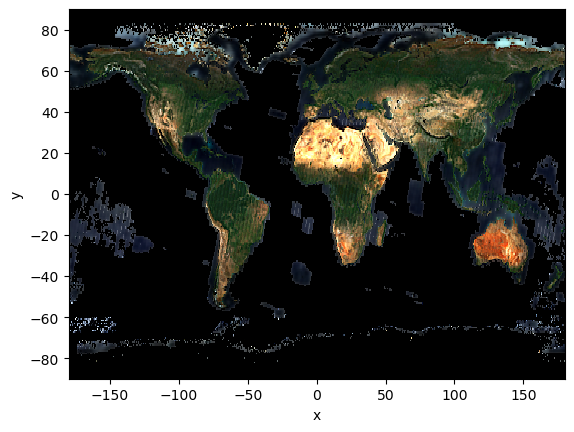

In [5]:
dataarray.plot.imshow()

Notice that most of the ocean areas are coloured black (pixel value 0) instead of
with a transparent colour. This is because `cog3pio=0.1.0` doesn't have the ability to
deal with NaN values yet, so you will need to manually handle this.

## Concatenate multiple single-band GeoTIFFs

Let's now try a slightly trickier set up - with bands stored in different files!

We'll use LandCoverNet images over Australia. Specifically, we'll read multiple
Sentinel-2 bands using
[`xr.open_mfdataset`](https://docs.xarray.dev/en/stable/generated/xarray.open_mfdataset.html),
ensuring that the list of URLs/filepaths correspond to the band order we want.

Note that some parameters are different than before:
- `concat_dim="band"` and `combine="nested"`: ensures that the bands are concatenated
  as data_vars along the dimension 'band'
- `device_id=None` (actually the default setting): so that the data is decoded by
  whatever GPU is available (usually this is the first CUDA GPU device, unless you are
  using dask-cuda with multiple GPUs).

In [6]:
dataset: xr.Dataset = xr.open_mfdataset(
    paths=[
        "https://data.source.coop/radiantearth/landcovernet/landcovernet_au/data/v1.0/2018/56JMS/16/S2/56JMS_16_20180214/56JMS_16_20180214_B04_10m.tif",
        "https://data.source.coop/radiantearth/landcovernet/landcovernet_au/data/v1.0/2018/56JMS/16/S2/56JMS_16_20180214/56JMS_16_20180214_B03_10m.tif",
        "https://data.source.coop/radiantearth/landcovernet/landcovernet_au/data/v1.0/2018/56JMS/16/S2/56JMS_16_20180214/56JMS_16_20180214_B02_10m.tif",
    ],
    engine="cog3pio",
    concat_dim="band",
    combine="nested",
    device_id=None,
    parallel=True,
)
dataset

<xarray.Dataset> Size: 397kB
Dimensions:  (band: 3, y: 256, x: 256)
Coordinates:
  * band     (band) uint8 3B 0 0 0
  * y        (y) float64 2kB 7.187e+06 7.187e+06 ... 7.184e+06 7.184e+06
  * x        (x) float64 2kB 4.962e+05 4.962e+05 ... 4.988e+05 4.988e+05
Data variables:
    raster   (band, y, x) uint16 393kB dask.array<chunksize=(1, 256, 256), meta=np.ndarray>

Next, we'll retrieve the 'raster' xarray.DataArray data_var from the xarray.Dataset,
and then call [`.load()`](https://docs.xarray.dev/en/stable/generated/xarray.Dataset.load.html)
to materialize the actual array into memory. This is because `xr.open_mfdataset` does
lazy loading into Dask arrays by default, but we want CuPy arrays!

In [7]:
raster: xr.DataArray = dataset.raster.load() # TODO: needs patched xarray
# assert isinstance(raster.data, cp.ndarray) # TODO: dask loads into numpy, not cupy ☹️
raster

<xarray.DataArray 'raster' (band: 3, y: 256, x: 256)> Size: 393kB
array([[[ 395,  404,  412, ...,  423,  437,  481],
        [ 397,  412,  412, ...,  404,  456,  523],
        [ 398,  401,  408, ...,  420,  502,  560],
        ...,
        [ 360,  353,  361, ...,  373,  455,  457],
        [ 364,  361,  370, ...,  324,  376,  382],
        [ 372,  366,  370, ...,  339,  340,  356]],

       [[ 763,  743,  742, ...,  787,  824,  905],
        [ 729,  743,  761, ...,  787,  869,  963],
        [ 743,  746,  749, ...,  783,  895, 1005],
        ...,
        [ 715,  744,  753, ...,  507,  536,  508],
        [ 741,  736,  746, ...,  488,  520,  487],
        [ 741,  736,  744, ...,  479,  491,  487]],

       [[ 682,  689,  721, ...,  671,  700,  754],
        [ 695,  714,  703, ...,  675,  745,  781],
        [ 691,  711,  702, ...,  668,  754,  819],
        ...,
        [ 682,  696,  702, ...,  296,  332,  313],
        [ 697,  714,  689, ...,  288,  313,  280],
        [ 703,  700,  692, ...,  274,  283,  266]]],
      shape=(3, 256, 256), dtype=uint16)
Coordinates:
  * band     (band) uint8 3B 0 0 0
  * y        (y) float64 2kB 7.187e+06 7.187e+06 ... 7.184e+06 7.184e+06
  * x        (x) float64 2kB 4.962e+05 4.962e+05 ... 4.988e+05 4.988e+05

Finally, we'll plot the RGB image. This is over a location at Hervey Bay, north of
Sunshine Coast in Queensland, Australia.

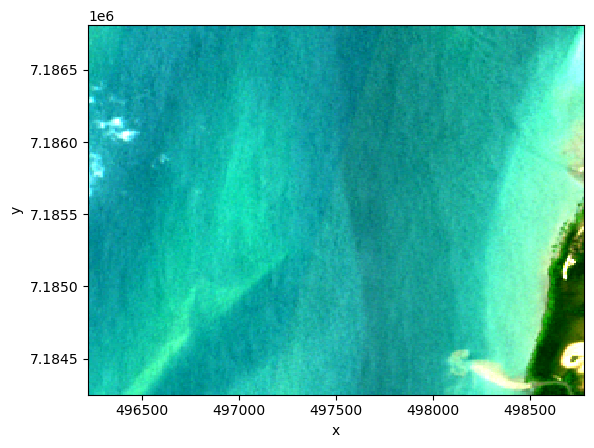

In [8]:
raster.plot.imshow(robust=True)

There's some cloud to the left, mostly water in the middle, and a strip of land on the
right. See if it matches with the label classifications
[here](https://source.coop/radiantearth/landcovernet/landcovernet_au/data/v1.0/2018/56JMS/16/56JMS_16_2018_LC_10m.tif).

# Summary

Awesome, you've now learned how to read GeoTIFFs into CUDA GPU memory, and uncovered
some of the limitations such as no NaN handling and lack of support for certain
compression types (TODO). This is a work in progress though, so feel free to open
issues to contribute improvements if you're keen to help!

```{seealso}

- [Accelerating GeoTIFF readers with Rust - FOSS4G 2025 talk](https://github.com/weiji14/foss4g2025/releases/tag/v1.0.0)
- [Decode GeoTIFF to GPU memory post on Pangeo forum](https://discourse.pangeo.io/t/decode-geotiff-to-gpu-memory/5214/)
- [GeoTIFF to GPU 3 part blog series](https://weiji14.xyz/blog/geotiffs-to-gpus-part-1:-an-unexpected-conflict-multi-threaded-reads-too-many-jobs/)
```